# FeatureLiftBench failure attribution: 550 frozen OpenHands runs

This notebook compares competing bottleneck hypotheses rather than treating token use,
repeated reads, or dynamic labels as causal explanations. It rebuilds the stage-level
audit table from trajectories, evaluator logs, task metadata, oracle manifests, and the
150-task taxonomy. Hidden-test source is not used to derive agent-side behavior features.

## Definitions and evidence rules

- **Formal pass** is the frozen suite `run_status == passed` outcome.
- **Dynamic-runtime task (primary definition)** is outcome-blind and requires an annotated
  cross-call/module/process mechanism: dynamic import, global/session/lifecycle state,
  framework lifecycle, environment/config, or packaged-resource coupling. Local parser
  state alone is not sufficient.
- **Earliest failure stage** is a conservative rule-based attribution. Direct evaluator
  import/isolation failures are high confidence; dynamic semantics is at most medium
  confidence because runtime-state gold remains unresolved.
- **Repeated read** means the same source-repository file was viewed again; source files
  are immutable during a run, so these are known unchanged reads.
- Regression controls are descriptive: model, split, task snapshot LOC, reference LOC,
  public-test count, and entanglement count. Condensation and repeated reads are
  post-treatment trajectory variables and are never interpreted causally.

In [1]:
from pathlib import Path
import json, os, subprocess, sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd()
if not (HERE / "build_failure_attribution.py").is_file():
    HERE = HERE / "reports" / "failure_attribution_20260720"
os.environ.setdefault("MPLCONFIGDIR", "/tmp/flb-failure-mpl")
subprocess.run([sys.executable, str(HERE / "build_failure_attribution.py")], cwd=HERE, check=True)

df = pd.read_csv(HERE / "trajectory_stage_labels_550.csv")
stage = pd.read_csv(HERE / "failure_stage_distribution.csv")
funnel = pd.read_csv(HERE / "failure_funnel.csv")
outcome_funnel = pd.read_csv(HERE / "outcome_funnel.csv")
dynamic = pd.read_csv(HERE / "dynamic_comparison.csv")
dynamic_by = pd.read_csv(HERE / "dynamic_by_model_split.csv")
regression = pd.read_csv(HERE / "regression_results.csv")
cases = pd.read_csv(HERE / "representative_cases.csv")
quality = json.loads((HERE / "data_quality.json").read_text())
FIG = HERE / "figures"
FIG.mkdir(exist_ok=True)
quality

{
  "data_quality": {
    "rows": 550,
    "unique_runs": 550,
    "unique_model_task_pairs": 550,
    "unique_tasks": 150,
    "trajectory_coverage": 550,
    "evaluation_coverage": 533,
    "taxonomy_join_coverage": 550,
    "duplicate_run_ids": 0,
    "token_identity_mismatches": 0,
    "oracle_file_manifest_tasks": 150,
    "clean_install_executed_runs": 0,
    "context_window_unique": [
      131072,
      204800
    ],
    "runtime_gold_limit": "closure_gold marks runtime_state and symbol completeness unresolved for the audited task set"
  },
  "runs": 550,
  "formal_passes": 225,
  "nonpasses": 325,
  "public_pass_hidden_fail": 173,
  "condensation_runs": 288,
  "condensation_events": 552,
  "context_truncated_runs": 31,
  "memory_loss_candidates": 58,
  "stage_counts": {
    "dependency_discovery": 85,
    "implementation": 80,
    "evaluator_or_environment": 62,
    "dynamic_semantics": 43,
    "budget_exhaustion": 32,
    "boundary_recovery": 15,
    "localization": 5,
    "v

{'rows': 550,
 'unique_runs': 550,
 'unique_model_task_pairs': 550,
 'unique_tasks': 150,
 'trajectory_coverage': 550,
 'evaluation_coverage': 533,
 'taxonomy_join_coverage': 550,
 'duplicate_run_ids': 0,
 'token_identity_mismatches': 0,
 'oracle_file_manifest_tasks': 150,
 'clean_install_executed_runs': 0,
 'context_window_unique': [131072, 204800],
 'runtime_gold_limit': 'closure_gold marks runtime_state and symbol completeness unresolved for the audited task set'}

## Data quality and coverage

In [2]:
assert len(df) == 550
assert df.run_id.nunique() == 550
assert df[["model", "task_id"]].drop_duplicates().shape[0] == 550
assert (df.total_tokens == df.prompt_tokens + df.completion_tokens).all()
assert int(df.events_available.sum()) == 550
assert int(df.evaluation_available.sum()) == 533

pd.DataFrame({
    "check": [
        "trajectory logs", "evaluator results", "taxonomy joins", "clean-install executions",
        "runtime/symbol gold completeness",
    ],
    "result": [
        "550/550", "533/550", "550/550", "0/550",
        "unresolved; stage labels are evidence-assisted, not human gold",
    ],
})

,check,result
0,trajectory logs,550/550
1,evaluator results,533/550
2,taxonomy joins,550/550
3,clean-install executions,0/550
4,runtime/symbol gold completeness,unresolved; stage labels are evidence-assisted...


The largest measurement limitation is not token completeness—it is semantic ground truth.
All token/event records are present, but no run performed a real clean install and the
closure annotations explicitly leave symbol and runtime-state completeness unresolved.

## Outcome and diagnostic funnels

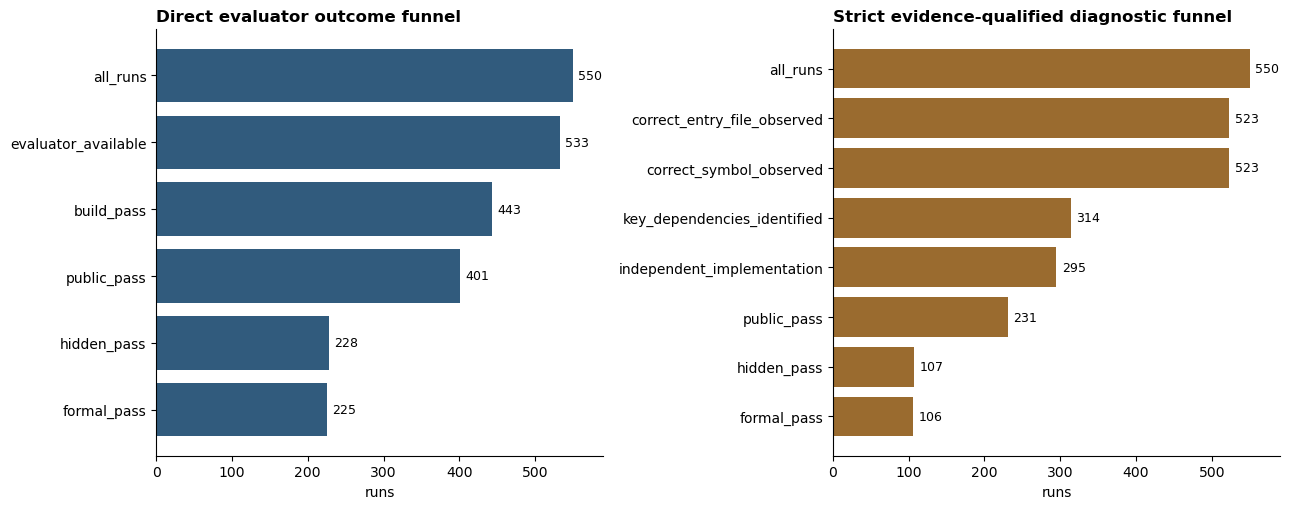

,stage,runs,share_of_550,stage_unknown_overall
0,all_runs,550,1.000000,0
1,correct_entry_file_observed,523,0.950909,27
2,correct_symbol_observed,523,0.950909,27
3,key_dependencies_identified,314,0.570909,216
4,independent_implementation,295,0.536364,17
5,public_pass,231,0.420000,107
6,hidden_pass,107,0.194545,107
7,formal_pass,106,0.192727,0


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for ax, data, title, color in [
    (axes[0], outcome_funnel, "Direct evaluator outcome funnel", "#315B7D"),
    (axes[1], funnel, "Strict evidence-qualified diagnostic funnel", "#9A6B2F"),
]:
    shown = data.iloc[::-1]
    ax.barh(shown.stage, shown.runs, color=color)
    for i, v in enumerate(shown.runs):
        ax.text(v + 7, i, f"{int(v)}", va="center", fontsize=9)
    ax.set_xlim(0, 590)
    ax.set_xlabel("runs")
    ax.set_title(title, loc="left", fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG / "failure_funnels.png", dpi=180, bbox_inches="tight")
plt.show()
funnel

The diagnostic funnel is intentionally strict and not a second success-rate measure.
Only 106 formal passes also have every preceding trajectory-derived stage positively
observed. In particular, 216 runs have **unknown**, not failed, direct-dependency status.
The direct outcome funnel remains the authoritative 225/550 pass count.

## Earliest failure-stage distribution

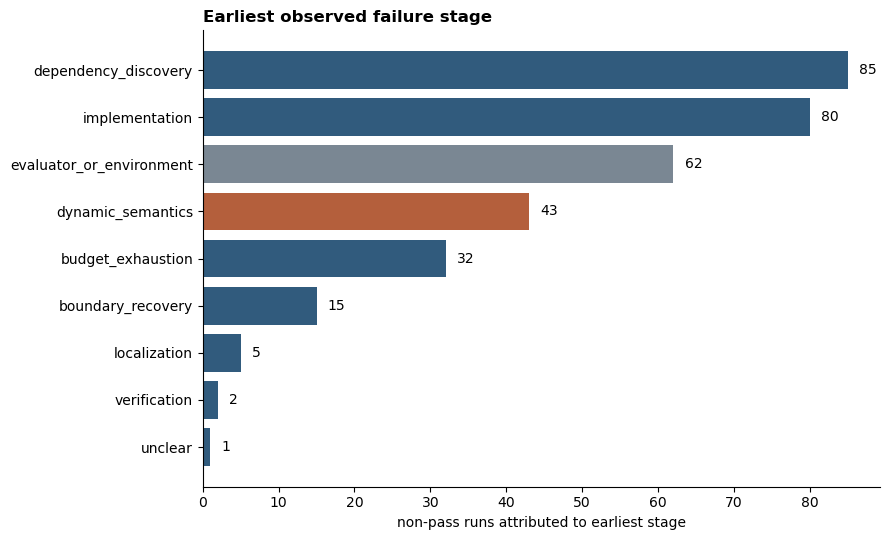

,earliest_failure_stage,primary_hypothesis,failure_subtype,failures,median_tokens,median_repeated_reads,models,tasks,share_of_failures,success_rate
0,dependency_discovery,H2,verification,85,1856717.0,2.0,4,49,0.261538,0.0
1,implementation,H5,verification,71,1286141.0,1.0,4,44,0.218462,0.0
2,evaluator_or_environment,H8,none,62,2722537.0,3.0,4,23,0.190769,0.0
3,dynamic_semantics,H3,capability_or_implementation,37,1094500.0,0.0,4,21,0.113846,0.0
4,budget_exhaustion,H7,exploration_policy_or_budget,17,4377780.0,4.0,3,17,0.052308,0.0
5,boundary_recovery,H4,verification,15,2200698.0,2.0,4,12,0.046154,0.0
6,budget_exhaustion,H7,workflow_failure,14,312369.0,0.5,3,14,0.043077,0.0
7,implementation,H5,none,9,2463546.0,1.0,2,9,0.027692,0.0
8,localization,H1,none,5,166556.0,0.0,3,4,0.015385,0.0
9,dynamic_semantics,H3,exploration_policy,4,2573681.5,2.5,2,4,0.012308,0.0


In [4]:
stage_total = stage.groupby("earliest_failure_stage", as_index=False).agg(
    failures=("failures", "sum"), median_tokens=("median_tokens", "median")
).sort_values("failures")
colors = ["#7A8793" if x == "evaluator_or_environment" else "#B45F3C" if x == "dynamic_semantics" else "#315B7D" for x in stage_total.earliest_failure_stage]
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(stage_total.earliest_failure_stage, stage_total.failures, color=colors)
for i, v in enumerate(stage_total.failures):
    ax.text(v + 1.5, i, f"{int(v)}", va="center")
ax.set_xlabel("non-pass runs attributed to earliest stage")
ax.set_title("Earliest observed failure stage", loc="left", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG / "failure_stage_distribution.png", dpi=180, bbox_inches="tight")
plt.show()
stage

Infrastructure failures (62) are retained in the 550 denominator but separated from agent
bottlenecks. Among 263 non-infrastructure failures, dependency/API closure and ordinary
implementation errors dominate. Dynamic-semantics candidates are a smaller, less certain
category; budget exhaustion is directly observed only for explicit step/timeout/workflow exits.

## Dynamic-runtime versus relatively static tasks

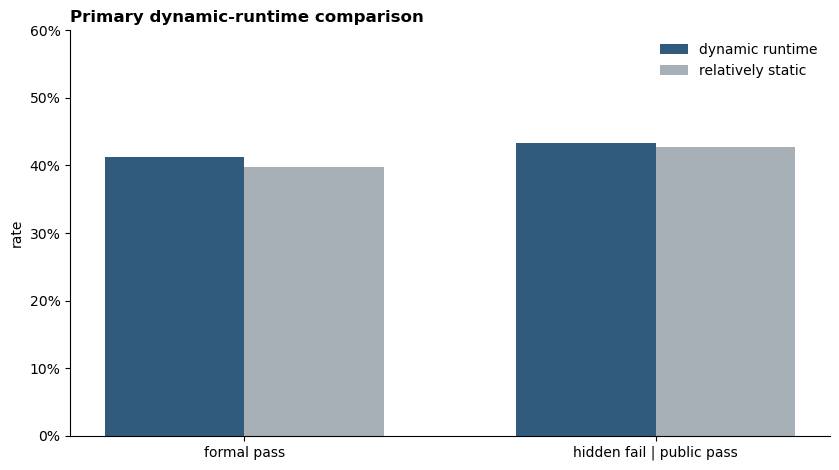

,group,runs,tasks,formal_passes,pass_rate,pass_ci_low,pass_ci_high,public_pass_hidden_fail,hidden_failure_rate_given_public,hidden_pass_rate_observed,median_tokens,median_repeated_reads,repeat_read_affected_rate,runtime_probe_rate,dynamic_probe_rate,dynamic_recognition_rate,fresh_final_verification_rate,condensation_rate
0,dynamic_runtime,432,117,178,0.412037,0.366596,0.459029,138,0.432602,0.518625,1505739.0,1.0,0.541667,0.826389,0.277778,0.678241,0.807870,0.509259
1,relatively_static,118,33,47,0.398305,0.314525,0.488498,35,0.426829,0.500000,1654110.5,2.0,0.618644,0.864407,0.033898,0.144068,0.822034,0.576271


In [5]:
primary = dynamic[dynamic.group.isin(["dynamic_runtime", "relatively_static"])].copy()
plot = primary.melt(
    id_vars="group",
    value_vars=["pass_rate", "hidden_failure_rate_given_public"],
    var_name="metric", value_name="rate",
)
labels = {"dynamic_runtime": "dynamic runtime", "relatively_static": "relatively static"}
metrics = ["pass_rate", "hidden_failure_rate_given_public"]
x = np.arange(len(metrics)); width = 0.34
fig, ax = plt.subplots(figsize=(8.5, 4.8))
for j, group in enumerate(["dynamic_runtime", "relatively_static"]):
    vals = [float(plot[(plot.group == group) & (plot.metric == m)].rate.iloc[0]) for m in metrics]
    ax.bar(x + (j - .5) * width, vals, width, label=labels[group], color=["#315B7D", "#A7B0B7"][j])
ax.set_xticks(x, ["formal pass", "hidden fail | public pass"])
ax.set_ylim(0, .6)
ax.set_ylabel("rate")
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.0%}")
ax.legend(frameon=False)
ax.set_title("Primary dynamic-runtime comparison", loc="left", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG / "dynamic_static_comparison.png", dpi=180, bbox_inches="tight")
plt.show()
primary

In [6]:
dynamic_by[[
    "model", "split", "dynamic_runtime_task", "runs", "pass_rate",
    "hidden_failure_rate_given_public", "median_tokens", "repeat_read_affected_rate",
    "runtime_probe_rate", "fresh_final_verification_rate",
]].sort_values(["model", "split", "dynamic_runtime_task"])

,model,split,dynamic_runtime_task,runs,pass_rate,hidden_failure_rate_given_public,median_tokens,repeat_read_affected_rate,runtime_probe_rate,fresh_final_verification_rate
0,deepseek/deepseek-v4-flash,core100,False,19,0.947368,0.052632,1473748.0,0.736842,1.000000,0.789474
1,deepseek/deepseek-v4-flash,core100,True,81,0.802469,0.129870,1584720.0,0.567901,0.962963,0.716049
2,deepseek/deepseek-v4-flash,hard50,False,14,0.071429,0.916667,1911806.5,0.714286,1.000000,0.785714
3,deepseek/deepseek-v4-flash,hard50,True,36,0.194444,0.787879,1704291.0,0.472222,0.972222,0.638889
4,openai/Qwen3-Coder-30B-A3B-Instruct,core100,False,19,0.263158,0.285714,2214005.0,0.473684,0.947368,0.842105
5,openai/Qwen3-Coder-30B-A3B-Instruct,core100,True,81,0.234568,0.622642,1875597.0,0.518519,0.938272,0.913580
6,openai/Qwen3.6-27B-FP8,core100,False,19,0.631579,0.000000,1449775.0,0.684211,0.842105,0.947368
7,openai/Qwen3.6-27B-FP8,core100,True,81,0.518519,0.176471,1618604.0,0.567901,0.703704,0.864198
8,openai/Qwen3.6-27B-FP8,hard50,False,14,0.000000,1.000000,1142935.5,0.500000,0.785714,0.785714
9,openai/Qwen3.6-27B-FP8,hard50,True,36,0.111111,0.866667,709008.0,0.472222,0.666667,0.694444


The aggregate difference is near zero and changes across subsets: dynamic tasks underperform
within Core-100 cells but outperform within Hard50 cells where both groups perform poorly.
This interaction and the incomplete model×subset design make pooled causal claims unsafe.

## Adjusted observational models

In [7]:
regression

,specification,term,odds_ratio,ci_low,ci_high,p_value,n,clusters,pseudo_r2
0,primary_preoutcome,dynamic_int,1.157611,0.539902,2.482051,0.706841,550,150,0.354629
1,primary_split_interaction,dynamic_int,0.853046,0.368457,1.974958,0.710571,550,150,0.362974
2,primary_split_interaction,dynamic_int:C(split)[T.hard50],10.072135,0.746682,135.864950,0.081868,550,150,0.362974
3,primary_plus_trajectory,dynamic_int,1.100661,0.511945,2.366379,0.806001,550,150,0.357121
4,primary_plus_trajectory,condensation_any,0.699668,0.371890,1.316344,0.268034,550,150,0.357121
5,primary_plus_trajectory,repeat_any,0.974737,0.547229,1.736222,0.930772,550,150,0.357121
6,legacy_definition_sensitivity,legacy_dynamic_int,1.259817,0.630769,2.516197,0.512862,550,150,0.355454


The primary adjusted odds ratio for **success** on dynamic tasks is 1.16 (95% CI 0.54–2.48).
The split interaction is large but extremely imprecise. Adding condensation and unchanged
repeated reads does not make either significant. These models rule out neither moderate harm
nor moderate benefit; they do rule out treating the observed labels as a demonstrated main cause.

## Capability, exploration policy, and memory/state management

In [8]:
df[df.earliest_failure_stage.eq("dynamic_semantics")].groupby(
    ["failure_subtype", "attribution_confidence"], as_index=False
).agg(
    runs=("run_id", "size"), tasks=("task_id", "nunique"), median_tokens=("total_tokens", "median"),
    runtime_probes=("runtime_probe_count", "sum"), dynamic_probes=("dynamic_runtime_probe_count", "sum"),
    recognition_rate=("dynamic_dependency_recognized", "mean"),
)

,failure_subtype,attribution_confidence,runs,tasks,median_tokens,runtime_probes,dynamic_probes,recognition_rate
0,capability_or_implementation,medium,37,21,1094500.0,244,110,1.0
1,exploration_policy,medium,4,4,2573681.5,28,0,0.0
2,memory_state_management,weak,2,2,2031538.5,15,0,1.0


Only two cases meet the weak memory-loss heuristic (dynamic information appeared before a
condensation, was absent later, and was not retained by the summary). That is not enough to
identify summarization as a root cause. Most dynamic candidates explicitly recognized the
mechanism and ran targeted probes, leaving capability versus ordinary implementation unresolved.

## Representative evidence cases

In [9]:
cases[[
    "task_id", "model", "earliest_failure_stage", "failure_subtype",
    "missed_behavior_or_dependency", "agent_actual_behavior",
    "discovered_or_forgotten", "most_likely_intervention",
]]

,task_id,model,earliest_failure_stage,failure_subtype,missed_behavior_or_dependency,agent_actual_behavior,discovered_or_forgotten,most_likely_intervention
0,pytest__fixture_resolve_core__001,openai/Qwen3-Coder-30B-A3B-Instruct,boundary_recovery,verification,fixture lookup error lists available,"closure-read coverage 100%; runtime probes 3, ...",recognized and retained/used incompletely,forbidden-import audit plus clean isolation check
1,responses__request_matcher_core__hard3_001,openai/Qwen3.6-35B-A3B-FP8,boundary_recovery,verification,query and header matchers and once behavior,"closure-read coverage 100%; runtime probes 7, ...",recognized and retained/used incompletely,forbidden-import audit plus clean isolation check
2,lark__visitor_transform_core__001,openai/Qwen3.6-27B-FP8,budget_exhaustion,exploration_policy_or_budget,missing exported API: Discard,closure-read coverage unknown; runtime probes ...,possible post-condensation loss; weak heuristi...,phase budget with earlier stop/prune policy
3,pygments__lexer_core__001,openai/Qwen3-Coder-30B-A3B-Instruct,budget_exhaustion,exploration_policy_or_budget,string and comment tokens are distinct,closure-read coverage unknown; runtime probes ...,possible post-condensation loss; weak heuristi...,phase budget with earlier stop/prune policy
4,isort__settings_resolver_core__hard3_001,openai/Qwen3.6-35B-A3B-FP8,dependency_discovery,verification,missing exported API: ProfileDoesNotExist,"closure-read coverage 100%; runtime probes 2, ...",recognized and retained/used incompletely,dependency/API closure hint and import-surface...
5,passlib__hash_context_core__001,openai/Qwen3-Coder-30B-A3B-Instruct,dependency_discovery,verification,missing behavior/API member: identify,closure-read coverage unknown; runtime probes ...,possible post-condensation loss; weak heuristi...,dependency/API closure hint and import-surface...
6,pendulum__parse_format_core__001,deepseek/deepseek-v4-flash,dependency_discovery,verification,missing behavior/API member: remaining_days,"closure-read coverage 78%; runtime probes 15, ...",recognized and retained/used incompletely,dependency/API closure hint and import-surface...
7,transitions__state_machine_core__hard3_001,deepseek/deepseek-v4-flash,dependency_discovery,verification,missing behavior/API member: parent,"closure-read coverage 100%; runtime probes 16,...",not explicitly discovered in agent-authored re...,dependency/API closure hint and import-surface...
8,celery__signal_dispatch_core__hard3_001,openai/Qwen3.6-35B-A3B-FP8,dynamic_semantics,memory_state_management,weak receiver cleanup after sender deletion,"closure-read coverage 100%; runtime probes 4, ...",possible post-condensation loss; weak heuristi...,evidence-pinned memory with invalidation
9,configobj__roundtrip_config_core__001,openai/Qwen3-Coder-30B-A3B-Instruct,dynamic_semantics,capability_or_implementation,comment preserved on write,"closure-read coverage 100%; runtime probes 11,...",recognized and retained/used incompletely,runtime trace plus behavior-differential probe


## Evidence boundary and causal experiments

### Supported now

- Direct evaluator attrition and outcome funnel counts.
- High-confidence API/dependency and forbidden-import failures.
- Explicit step/timeout/workflow truncation counts.
- Descriptive dynamic/static, condensation, token, probe, and repeated-read associations.

### Not supported now

- Dynamic-runtime coupling as the principal causal bottleneck.
- Repeated reads, high tokens, or condensation as causes of failure.
- A clean-install success rate: the evaluator used path imports in all 533 evaluated runs.
- A reliable memory-loss rate: summaries and runtime-state closure lack adjudicated gold.

### Required causal tests

1. Paired 2×2 on stratified dynamic/static tasks: default policy vs mandatory runtime probe;
   test the task-type×intervention interaction.
2. Dependency-hint arm vs runtime-trace arm vs extra-token arm with fixed model/task/seed and
   identical context window; attribute lift to closure, dynamic evidence, or budget.
3. Default condenser vs evidence-pinned memory at fixed token budget; pre-register retention,
   invalidation, and fresh-final-verification metrics.
4. Add a real wheel/venv clean-install gate before re-estimating packaging/boundary failures.